IDs encontrados: ['107', '43']

PROCESANDO CASO: 107
Dimensiones WSI: (87296, 198656)
Dimensiones thumbnail: (1758, 4000)


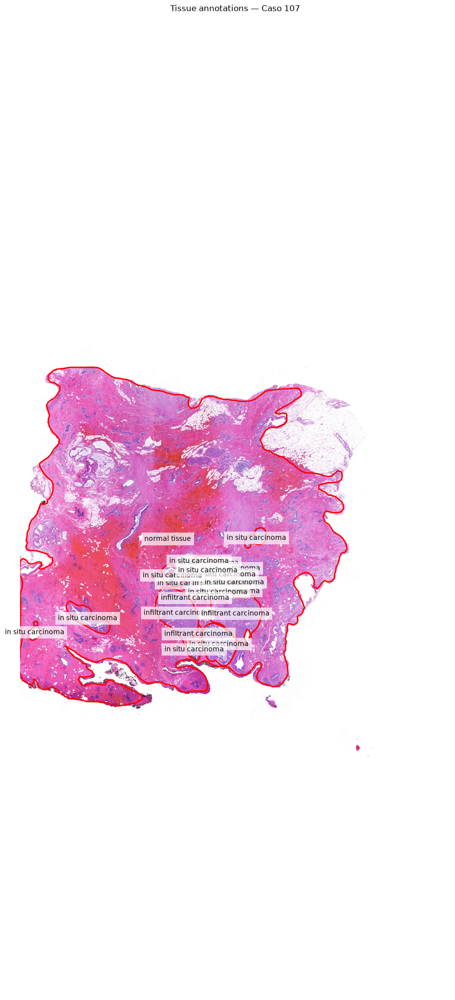

ℹ️  Sin anotaciones ROI para 107

PROCESANDO CASO: 43
Dimensiones WSI: (85248, 202752)
Dimensiones thumbnail: (1682, 4000)


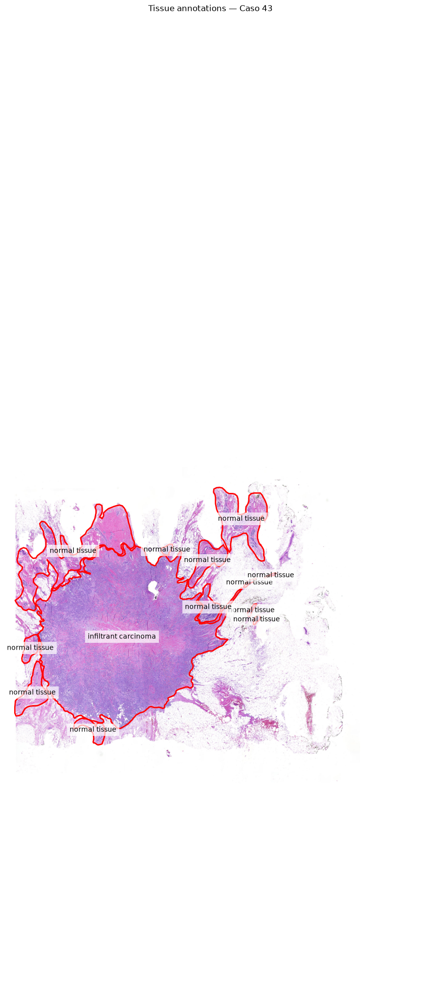

           name              class_name    class_color
0       IDC_C01  HSI Region of Interest  [255, 255, 0]
1       IDC_C02  HSI Region of Interest  [255, 255, 0]
2       IDC_C03  HSI Region of Interest  [255, 255, 0]
3       IDC_C04  HSI Region of Interest  [255, 255, 0]
4       IDC_C05  HSI Region of Interest  [255, 255, 0]
5       IDC_C06  HSI Region of Interest  [255, 255, 0]
6       IDC_C07  HSI Region of Interest  [255, 255, 0]
7       IDC_C08  HSI Region of Interest  [255, 255, 0]
8       IDC_C09  HSI Region of Interest  [255, 255, 0]
9       IDC_C10  HSI Region of Interest  [255, 255, 0]
10  Healthy_C01  HSI Region of Interest  [255, 255, 0]
11  Healthy_C02  HSI Region of Interest  [255, 255, 0]
12  Healthy_C03  HSI Region of Interest  [255, 255, 0]
13  Healthy_C04  HSI Region of Interest  [255, 255, 0]
14  Healthy_C05  HSI Region of Interest  [255, 255, 0]
[Healthy] HS_VNIR_43_Healthy_x10_C01 → shape: (600, 1004, 740)


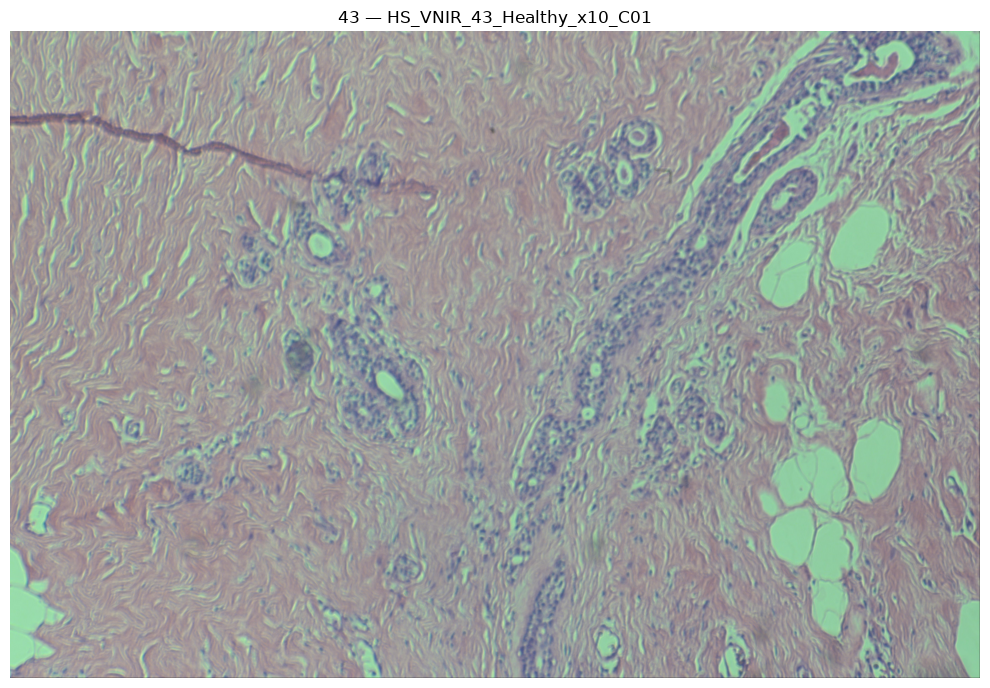

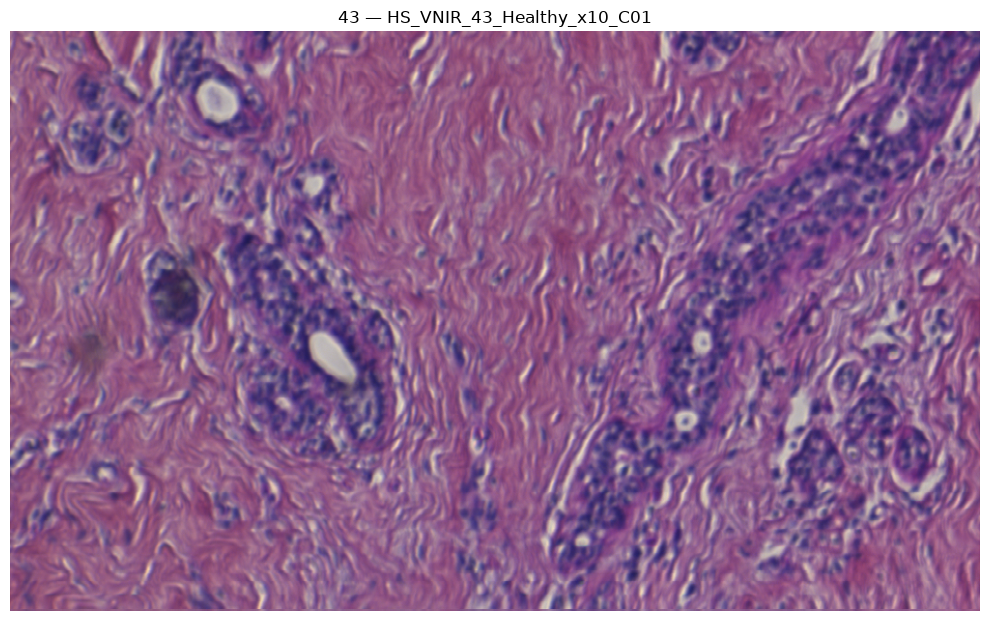

[Healthy] HS_VNIR_43_Healthy_x10_C02 → shape: (600, 1004, 740)


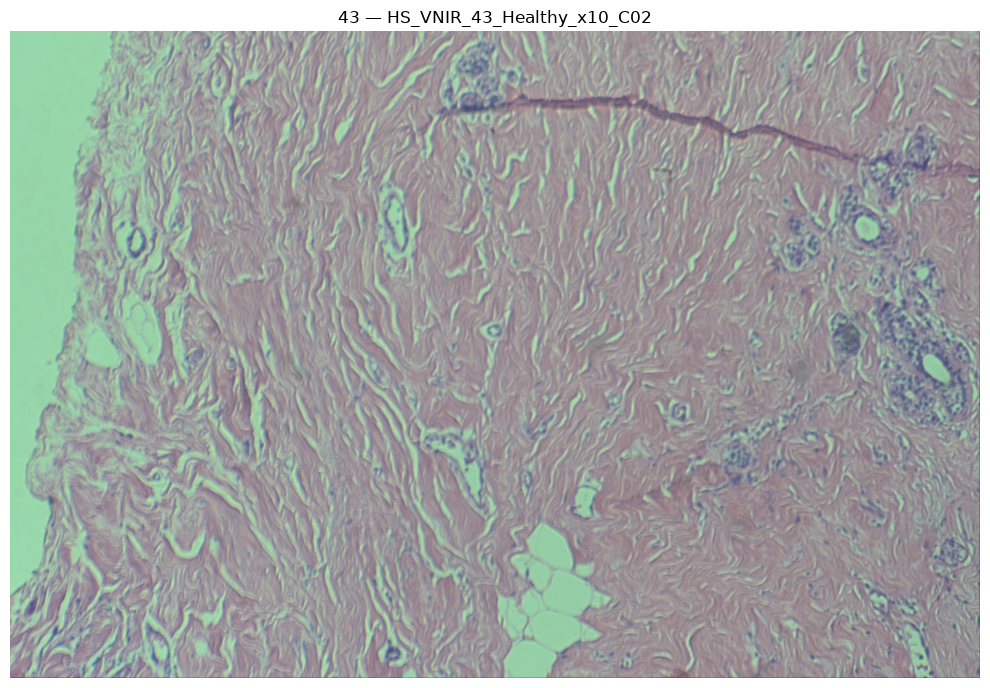

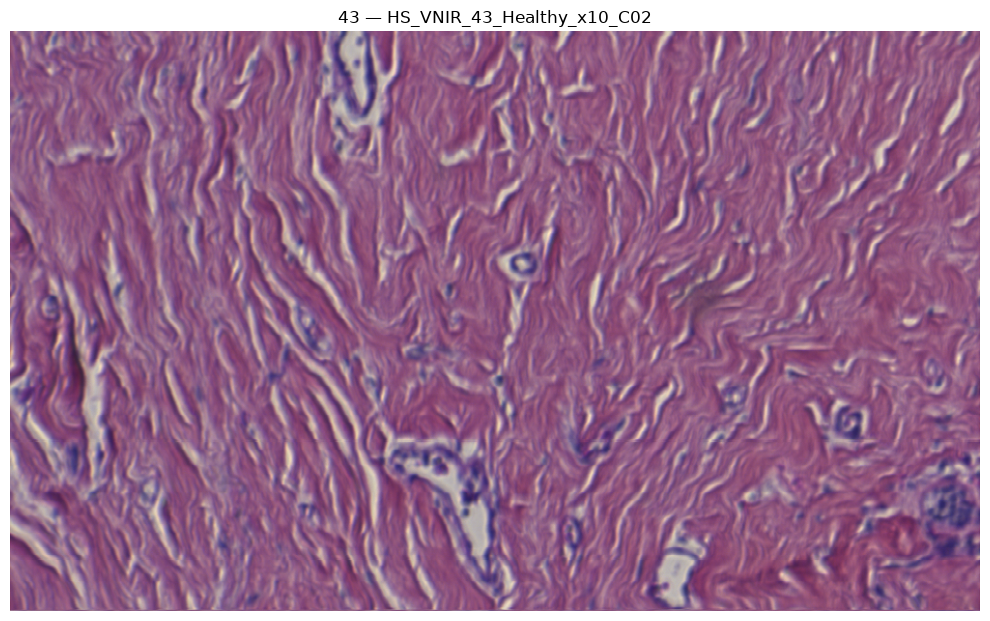

[IDC] HS_VNIR_43_IDC_x10_C01 → shape: (600, 1004, 740)


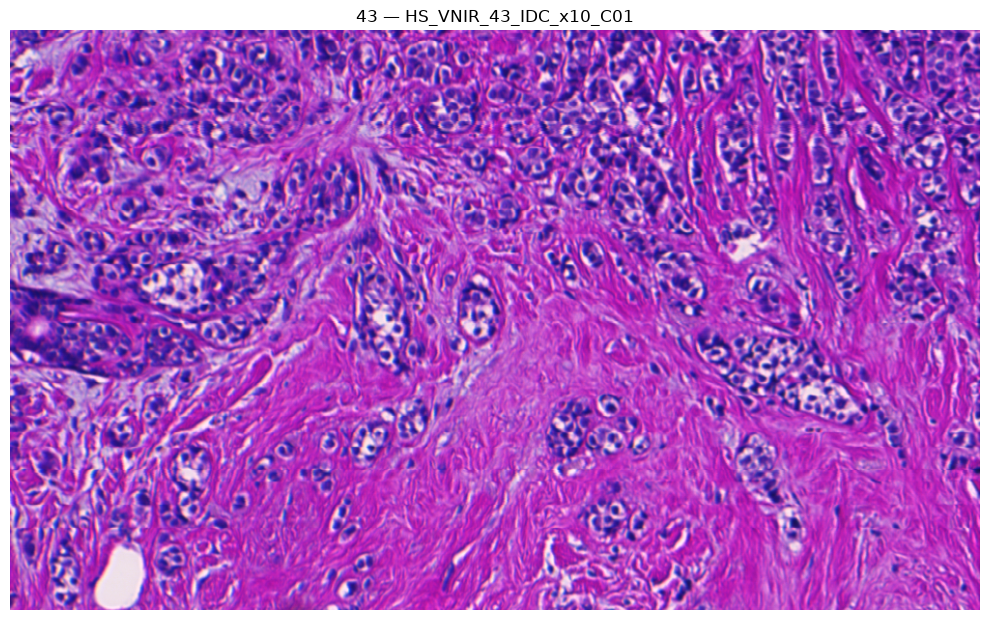

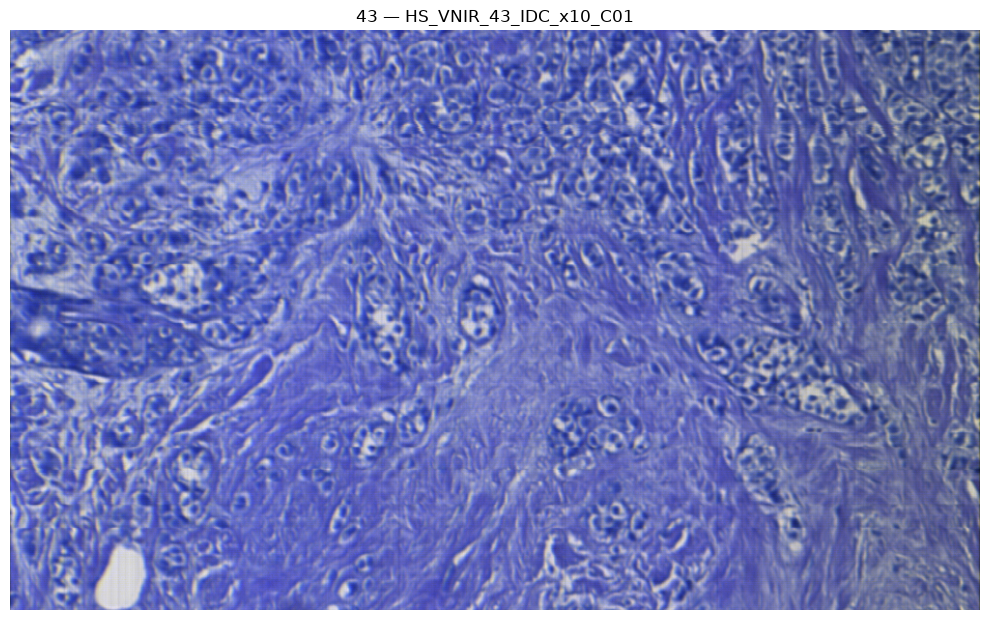

[IDC] HS_VNIR_43_IDC_x10_C02 → shape: (600, 1004, 740)


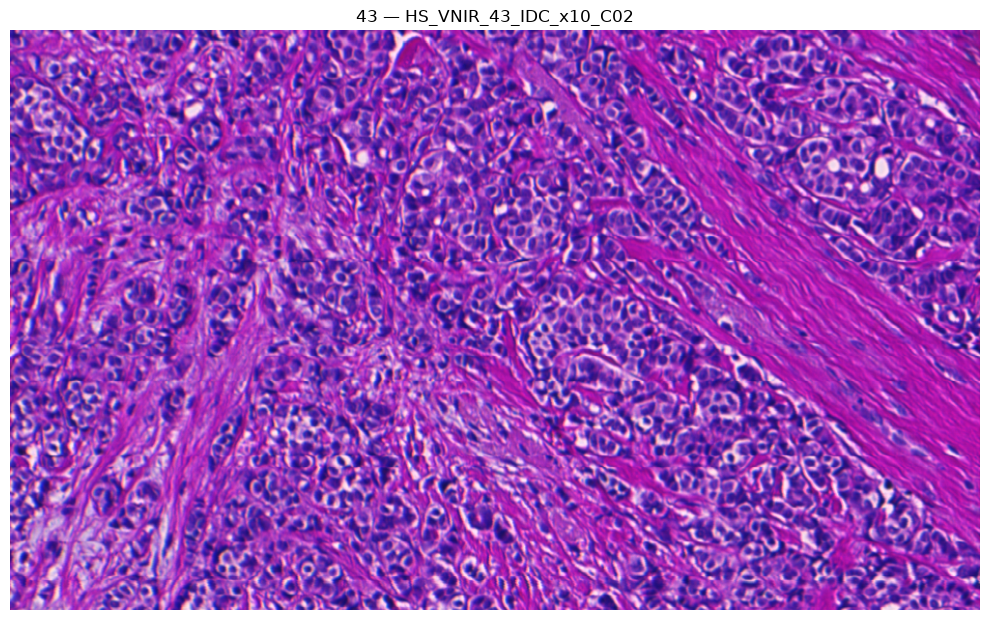

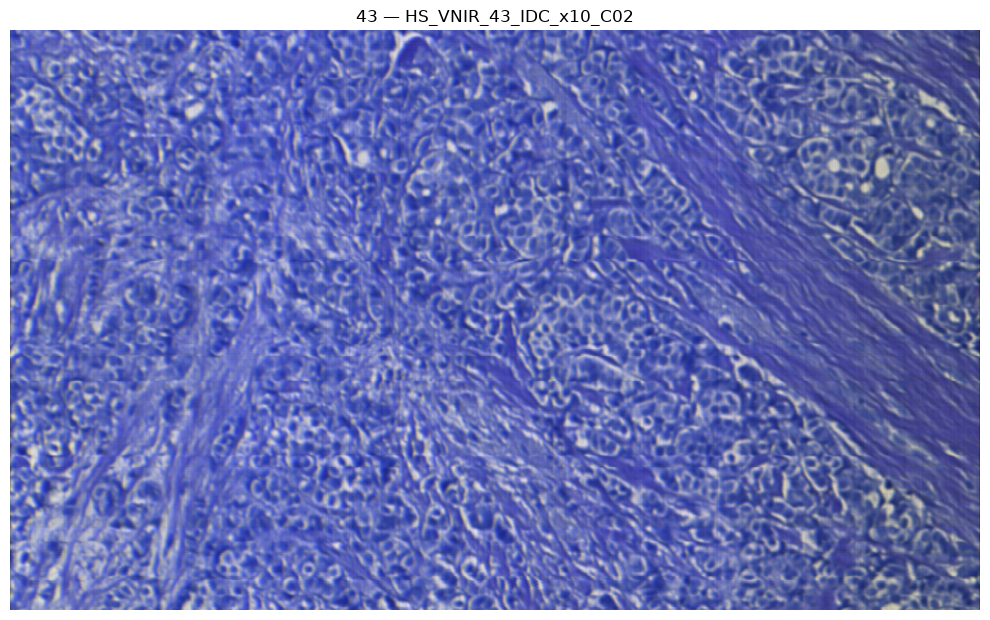


✅ Análisis completado.


In [3]:
#Intento uno para hacer loop
from pathlib import Path
import re
import openslide
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.affinity import translate, scale
from PIL import Image

# =========================================================
# CONFIGURACIÓN: rutas base
# =========================================================
BASE = Path("C:/Users/Abrah/OneDrive/Documents/Patologia Computacional/sample")

DIR_WSI       = BASE / "01_01_Histological_images"
DIR_TISSUE    = BASE / "01_02_Tissue_Annotations"
DIR_HSI_ROI   = BASE / "01_03_HSI-ROI_Annotations"
DIR_HS        = BASE / "02_01_HS_Images"

THUMB_SIZE = (4000, 4000)
FIGSIZE    = (12, 20)

# =========================================================
# FUNCIÓN AUXILIAR: transformar GeoDataFrame a coordenadas del thumbnail
# =========================================================
def escalar_geodataframe(gdf, slide, thumbnail):
    slide_w, slide_h = slide.dimensions
    thumb_w, thumb_h = thumbnail.size
    scale_x = thumb_w / slide_w
    scale_y = thumb_h / slide_h

    # OJO: bounds-x/y pueden no existir en todos los formatos
    bounds_x = int(slide.properties.get("openslide.bounds-x", 0))
    bounds_y = int(slide.properties.get("openslide.bounds-y", 0))

    gdf_thumb = gdf.copy()
    gdf_thumb["geometry"] = gdf_thumb["geometry"].apply(
        lambda geom: scale(
            translate(geom, xoff=bounds_x, yoff=bounds_y),
            xfact=scale_x, yfact=scale_y, origin=(0, 0)
        )
    )
    return gdf_thumb


# =========================================================
# FUNCIÓN AUXILIAR: extraer class_name / class_color
# =========================================================
def extraer_clases(gdf):
    if "classification" in gdf.columns:
        gdf["class_name"]  = gdf["classification"].apply(
            lambda x: x["name"]  if isinstance(x, dict) else None
        )
        gdf["class_color"] = gdf["classification"].apply(
            lambda x: x.get("color", "red") if isinstance(x, dict) else "red"
        )
    return gdf


# =========================================================
# FUNCIÓN PRINCIPAL: procesar un solo caso por ID
# =========================================================
def procesar_caso(case_id):
    print(f"\n{'='*60}")
    print(f"PROCESANDO CASO: {case_id}")
    print(f"{'='*60}")

    # --- 1. Abrir WSI ---
    wsi_path = DIR_WSI / f"{case_id}.mrxs"
    if not wsi_path.exists():
        print(f"⚠️  No existe WSI: {wsi_path}. Saltando.")
        return

    slide = openslide.OpenSlide(str(wsi_path))
    print(f"Dimensiones WSI: {slide.dimensions}")

    thumbnail = slide.get_thumbnail(THUMB_SIZE)
    print(f"Dimensiones thumbnail: {thumbnail.size}")

    # --- 2. Anotaciones de tejido ---
    tissue_path = DIR_TISSUE / f"{case_id}.geojson"
    if tissue_path.exists():
        gdf = gpd.read_file(tissue_path)
        gdf = extraer_clases(gdf)
        gdf_thumb = escalar_geodataframe(gdf, slide, thumbnail)

        # Dibujar bordes + etiquetas
        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.imshow(thumbnail)

        gdf_thumb.plot(ax=ax, facecolor="none",
                       edgecolor="red", linewidth=2, aspect="equal")

        ax.set_xlim(0, thumbnail.size[0])
        ax.set_ylim(thumbnail.size[1], 0)

        for _, row in gdf_thumb.iterrows():
            centroid = row.geometry.centroid
            label = row.get("class_name", "")
            if label:
                ax.text(centroid.x, centroid.y, label,
                        fontsize=10, ha="center", va="center",
                        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

        ax.axis("off")
        plt.tight_layout(pad=0)
        plt.title(f"Tissue annotations — Caso {case_id}")
        plt.show()
    else:
        print(f"ℹ️  Sin anotaciones de tejido para {case_id}")

    # --- 3. Anotaciones de ROI hiperespectral ---
    roi_path = DIR_HSI_ROI / f"{case_id}.geojson"
    if roi_path.exists():
        roi = gpd.read_file(roi_path)
        roi = extraer_clases(roi)
        print(roi[["name", "class_name", "class_color"]])
    else:
        print(f"ℹ️  Sin anotaciones ROI para {case_id}")

    # --- 4. Imágenes hiperespectrales auxiliares ---
    for categoria in ["Healthy", "IDC"]:
        cat_dir = DIR_HS / categoria
        if not cat_dir.exists():
            continue

        # Buscar cualquier subcarpeta que contenga el ID del caso
        candidatos = [d for d in cat_dir.iterdir() if d.is_dir() and f"_{case_id}_" in d.name]
        for caso_dir in candidatos:
            hdr = caso_dir / "calibrated.hdr"
            dat = caso_dir / "calibrated.dat"
            if hdr.exists() and dat.exists():
                import spectral as spy
                img = spy.envi.open(str(hdr), str(dat))
                print(f"[{categoria}] {caso_dir.name} → shape: {img.shape}")

            # Mostrar PNGs de esa carpeta
            for png_path in sorted(caso_dir.rglob("*.png")):
                im = Image.open(png_path)
                plt.figure(figsize=(10, 10))
                plt.imshow(im)
                plt.title(f"{case_id} — {png_path.parent.name}")
                plt.axis("off")
                plt.tight_layout()
                plt.show()


# =========================================================
# DESCUBRIR TODOS LOS IDs Y PROCESAR
# =========================================================
def descubrir_ids():
    """Devuelve lista de IDs (nombres de archivos .mrxs sin extensión)."""
    return sorted(p.stem for p in DIR_WSI.glob("*.mrxs"))


if __name__ == "__main__":
    ids = descubrir_ids()
    print(f"IDs encontrados: {ids}")

    for case_id in ids:
        try:
            procesar_caso(case_id)
        except Exception as e:
            print(f"❌ Error procesando {case_id}: {e}")

    print("\n✅ Análisis completado.")


In [ ]:
print("hello world")